# Same mdodel 
## Just use new .npy that use only mic channel

In [68]:
import os, random, json, math
from pathlib import Path
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.utils.data.sampler import WeightedRandomSampler

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
)

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from transformers import (
    Wav2Vec2Processor,
    Wav2Vec2ForSequenceClassification,
    get_linear_schedule_with_warmup
)

In [69]:
TRAIN_NPY_DIR = Path(r"C:\V89\data2\train_npy")
TEST_NPY_DIR  = Path(r"C:\V89\data_test\test_npy")

TRAIN_CSV = r"C:\V89\Snore_Apnea_Analyze\EDF_RML\data_csv\use_train\train\use_train.csv"
TEST_CSV  = r"C:\V89\Snore_Apnea_Analyze\EDF_RML\data_csv\use_test\test\use_test.csv"

SAVE_DIR  = Path(r"C:\V89\Snore_Apnea_Analyze\EDF_RML\binary_wav2vec2_npy_V3")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

In [70]:
TARGET_SR = 16000
SEGMENT_SECONDS = 5.0
SEG_SAMPLES = int(TARGET_SR * SEGMENT_SECONDS)
BATCH_SIZE = 4
EPOCHS = 20
LR = 1e-5
VAL_THRESHOLD = 0.50

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name())

Device: cuda
GPU: NVIDIA GeForce RTX 4060


In [71]:
APNEA_TYPES = {"Apnea","Hypopnea","CentralApnea","MixedApnea"}
NON_APNEA_TYPES = {"Snore"}

def map_type_to_label(t: str) -> int:
    if t in APNEA_TYPES: return 1
    if t in NON_APNEA_TYPES: return 0
    return 0

In [72]:
# =====================
df_train_all = pd.read_csv(TRAIN_CSV)
df_test_all  = pd.read_csv(TEST_CSV)

df_train_all["label"] = df_train_all["type"].map(map_type_to_label).astype(int)
df_test_all["label"]  = df_test_all["type"].map(map_type_to_label).astype(int)

train_df, val_df = train_test_split(
    df_train_all, test_size=0.2, stratify=df_train_all["label"], random_state=SEED
)
print("Train size:", len(train_df), "Val size:", len(val_df), "Test size:", len(df_test_all))

Train size: 619 Val size: 155 Test size: 595


In [73]:
def resolve_npy_path(root_dir: Path, pid: int, seg_index: int) -> Path | None:
    """
    patient_id + segment_index -> หาไฟล์ Mic .npy
    """
    pid_str = f"{int(pid):08d}"
    seg_str = f"[{int(seg_index)+1:03d}]"

    # common patterns
    candidates = [
        f"{pid_str}-100507{seg_str}_mic.npy",
        f"{pid_str}{seg_str}_mic.npy",
    ]

    for fname in candidates:
        path = root_dir / fname
        if path.exists():
            return path

    # fallback: ค้นหาไฟล์ที่มี pid + seg + _mic.npy
    hits = list(root_dir.rglob(f"*{pid_str}*{seg_str}*_mic.npy"))
    return hits[0] if hits else None



def load_mic_from_npy(npy_path: Path) -> np.ndarray | None:
    try:
        arr = np.load(npy_path).astype(np.float32)
        if arr.ndim > 1:
            arr = arr.reshape(-1)
        return arr
    except Exception as e:
        print(f"[load_mic_from_npy] error {npy_path}: {e}")
        return None

def slice_segment(wave: np.ndarray, start_sec: float, dur_sec: float,
                  sr: int = TARGET_SR, fixed_len: int = SEG_SAMPLES) -> np.ndarray | None:
    if wave is None or len(wave) == 0:
        return None
    start = int(max(0.0, float(start_sec)) * sr)
    end = start + int(float(dur_sec) * sr)
    if start >= len(wave):
        return None
    seg = wave[start:min(end, len(wave))]
    if len(seg) <= 0:
        return None
    if len(seg) < fixed_len:
        seg = np.pad(seg, (0, fixed_len - len(seg)), mode="constant")
    else:
        seg = seg[:fixed_len]
    return seg.astype(np.float32)

In [74]:
class W2V2NpyDataset(Dataset):
    def __init__(self, df: pd.DataFrame, npy_root: Path, target_sr=TARGET_SR, seg_seconds=SEGMENT_SECONDS):
        self.df = df.reset_index(drop=True)
        self.root = npy_root
        self.target_sr = target_sr
        self.seg_seconds = seg_seconds

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        try:
            r = self.df.iloc[idx]
            pid = int(r["patient_id"])
            seg_index = int(r["segment_index"])
            start_sec = float(r.get("segment_local_start_sec", r.get("start_sec", 0.0)))
            dur_sec   = min(float(r.get("duration_sec", self.seg_seconds)), self.seg_seconds)

            p = resolve_npy_path(self.root, pid, seg_index)
            if p is None or not p.exists():
                raise FileNotFoundError(f"No file for pid={pid} seg={seg_index}")

            wave = load_mic_from_npy(p)
            seg  = slice_segment(wave, start_sec, dur_sec, sr=self.target_sr, fixed_len=SEG_SAMPLES)
            if seg is None:
                seg = slice_segment(wave, 0.0, self.seg_seconds, sr=self.target_sr, fixed_len=SEG_SAMPLES)
                if seg is None:
                    raise RuntimeError(f"Empty segment for {p}")

            y = int(r["label"])
            return torch.tensor(seg), torch.tensor(y, dtype=torch.long)

        except Exception as e:
            print(f"[Dataset] Skipping index {idx} due to error: {e}")
            return torch.zeros(SEG_SAMPLES, dtype=torch.float32), torch.tensor(0)

In [75]:
PROCESSOR_NAME = "facebook/wav2vec2-base"
processor = Wav2Vec2Processor.from_pretrained(PROCESSOR_NAME)

def collate_w2v2(batch):
    waves, labels = zip(*batch)
    inputs = processor(
        [w.numpy() for w in waves],
        sampling_rate=TARGET_SR,
        return_tensors="pt",
        padding=True,
        max_length=SEG_SAMPLES,
        truncation=True,
    )
    return {
        "input_values": inputs.input_values,
        "attention_mask": inputs.attention_mask if "attention_mask" in inputs else None,
        "labels": torch.stack(labels),
    }

c:\V89\.venv\Lib\site-packages\transformers\configuration_utils.py:381: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(


In [76]:
train_ds = W2V2NpyDataset(train_df, TRAIN_NPY_DIR)
val_ds   = W2V2NpyDataset(val_df,   TRAIN_NPY_DIR)
test_ds  = W2V2NpyDataset(df_test_all, TEST_NPY_DIR)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_w2v2, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_w2v2, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                          collate_fn=collate_w2v2, num_workers=0, pin_memory=True)

In [77]:
model = Wav2Vec2ForSequenceClassification.from_pretrained(
    PROCESSOR_NAME,
    num_labels=2,
    problem_type="single_label_classification",
).to(device)

# freeze feature extractor
for p in model.wav2vec2.feature_extractor.parameters():
    p.requires_grad = False

Some weights of Wav2Vec2ForSequenceClassification were not initialized from the model checkpoint at facebook/wav2vec2-base and are newly initialized: ['wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'wav2vec2.encoder.pos_conv_embed.conv.parametrizations.weight.original1', 'classifier.bias', 'projector.bias', 'projector.weight', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [78]:
# =====================
cls_weights  = compute_class_weight(class_weight="balanced", classes=np.array([0,1]), y=train_df["label"].values)
cls_weights_t = torch.tensor(cls_weights, dtype=torch.float32, device=device)
print("Class weights:", cls_weights_t.cpu().numpy())

criterion = nn.CrossEntropyLoss(weight=cls_weights_t)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
total_steps = EPOCHS * math.ceil(len(train_loader))
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)


Class weights: [1.3878924  0.78156567]


In [79]:
def run_eval(dataloader, threshold=0.5):
    model.eval()
    all_true, all_pred = [], []
    running_loss = 0.0
    with torch.no_grad():
        for batch in dataloader:
            input_values = batch["input_values"].to(device)
            attention_mask = batch["attention_mask"].to(device) if batch["attention_mask"] is not None else None
            labels = batch["labels"].to(device)

            outputs = model(input_values, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            logits = outputs.logits

            probs = torch.softmax(logits, dim=1)[:, 1]
            preds = (probs >= threshold).long()

            running_loss += loss.item()
            all_true.extend(labels.cpu().numpy())
            all_pred.extend(preds.cpu().numpy())
    avg_loss = running_loss / max(1, len(dataloader))
    acc = (np.array(all_true) == np.array(all_pred)).mean()
    f1  = f1_score(all_true, all_pred, average="macro")
    return avg_loss, acc, f1, np.array(all_true), np.array(all_pred)

In [62]:
best_val_f1, best_epoch = 0.0, 0

for epoch in range(1, EPOCHS+1):
    model.train()
    tr_loss, tr_correct, tr_total = 0.0, 0, 0
    tr_true, tr_pred = [], []

    for batch in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [Train]"):
        input_values = batch["input_values"].to(device)
        attention_mask = batch["attention_mask"].to(device) if batch["attention_mask"] is not None else None
        labels = batch["labels"].to(device)

        optimizer.zero_grad()
        outputs = model(input_values, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        logits = outputs.logits
        loss.backward()
        optimizer.step()
        scheduler.step()

        tr_loss += loss.item()
        probs = torch.softmax(logits, dim=1)[:, 1]
        preds = (probs >= 0.5).long()
        tr_correct += (preds == labels).sum().item()
        tr_total += labels.size(0)
        tr_true.extend(labels.cpu().numpy()); tr_pred.extend(preds.cpu().numpy())

    train_acc = tr_correct / max(1, tr_total)
    train_f1  = f1_score(tr_true, tr_pred, average="macro")

    val_loss, val_acc, val_f1, _, _ = run_eval(val_loader, threshold=VAL_THRESHOLD)
    print(f"Epoch {epoch:02d} | "
          f"Train Loss {tr_loss/len(train_loader):.4f} Acc {train_acc:.4f} F1 {train_f1:.4f}  ||  "
          f"Val Loss {val_loss:.4f} Acc {val_acc:.4f} F1 {val_f1:.4f}")
    
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch = epoch
        best_model_dir = SAVE_DIR / "wav2vec2_best"
        best_model_dir.mkdir(parents=True, exist_ok=True)
        model.save_pretrained(str(best_model_dir))
        processor.save_pretrained(str(best_model_dir))
        print(f"✅ New best model saved! F1: {best_val_f1:.4f} at epoch {best_epoch}")


Epoch 1/20 [Train]:   0%|          | 0/155 [00:00<?, ?it/s]

c:\V89\.venv\Lib\site-packages\torch\_dynamo\eval_frame.py:838: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch 01 | Train Loss 0.3794 Acc 0.8546 F1 0.8407  ||  Val Loss 0.2054 Acc 0.9290 F1 0.9259
✅ New best model saved! F1: 0.9259 at epoch 1


Epoch 2/20 [Train]:   0%|          | 0/155 [00:00<?, ?it/s]

c:\V89\.venv\Lib\site-packages\torch\_dynamo\eval_frame.py:838: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


...

c:\V89\.venv\Lib\site-packages\torch\_dynamo\eval_frame.py:838: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch 19 | Train Loss 0.0049 Acc 1.0000 F1 1.0000  ||  Val Loss 0.0789 Acc 0.9806 F1 0.9789


Epoch 20/20 [Train]:   0%|          | 0/155 [00:00<?, ?it/s]

c:\V89\.venv\Lib\site-packages\torch\_dynamo\eval_frame.py:838: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch 20 | Train Loss 0.0051 Acc 1.0000 F1 1.0000  ||  Val Loss 0.0929 Acc 0.9742 F1 0.9718


In [63]:
final_model_dir = SAVE_DIR / "wav2vec2_final"
final_model_dir.mkdir(parents=True, exist_ok=True)
model.save_pretrained(str(final_model_dir))
processor.save_pretrained(str(final_model_dir))
print(f"\n✅ Final model saved to: {final_model_dir}")
print(f"📊 Training completed! Best validation F1: {best_val_f1:.4f} at epoch {best_epoch}")


✅ Final model saved to: C:\V89\Snore_Apnea_Analyze\EDF_RML\binary_wav2vec2_npy_V3\wav2vec2_final
📊 Training completed! Best validation F1: 0.9861 at epoch 5


In [64]:
import seaborn as sns

📊 Test Results
Loss: 0.6954
Accuracy: 0.8622
Macro F1: 0.8156

Classification Report:
               precision    recall  f1-score   support

           0     0.8476    0.9783    0.9083       415
           1     0.9224    0.5944    0.7230       180

    accuracy                         0.8622       595
   macro avg     0.8850    0.7864    0.8156       595
weighted avg     0.8702    0.8622    0.8522       595



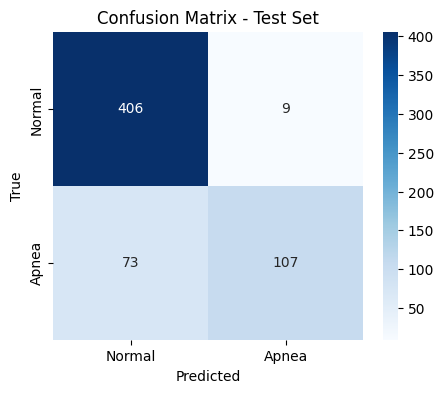

In [80]:
processor = Wav2Vec2Processor.from_pretrained(final_model_dir)
model = Wav2Vec2ForSequenceClassification.from_pretrained(final_model_dir).to(device)
model.eval()

test_loss, test_acc, test_f1, y_true, y_pred = run_eval(test_loader, threshold=VAL_THRESHOLD)

print("📊 Test Results")
print(f"Loss: {test_loss:.4f}")
print(f"Accuracy: {test_acc:.4f}")
print(f"Macro F1: {test_f1:.4f}")

print("\nClassification Report:\n", classification_report(y_true, y_pred, digits=4))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Normal","Apnea"], yticklabels=["Normal","Apnea"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Test Set")
plt.show()


In [66]:
import os

files = os.listdir(TEST_NPY_DIR)
print("First 10 test files:", files[:10])

df1010 = df_test_all[df_test_all["patient_id"] == 1010]
print("Test CSV rows for patient 1010:")
print(df1010.head())


First 10 test files: ['00000995-100507[001]_mic.npy', '00000995-100507[002]_mic.npy', '00000995-100507[003]_mic.npy', '00000995-100507[004]_mic.npy', '00000995-100507[005]_mic.npy', '00000999-100507[001]_mic.npy', '00000999-100507[002]_mic.npy', '00000999-100507[003]_mic.npy', '00000999-100507[004]_mic.npy', '00000999-100507[005]_mic.npy']
Test CSV rows for patient 1010:
   patient_id  event_id       family      type  start_sec  duration_sec  \
0        1010         3        Nasal     Snore       40.0           6.0   
1        1010         5        Nasal     Snore       57.5          17.0   
2        1010        12        Nasal     Snore       91.5          11.5   
3        1010        36  Respiratory  Hypopnea      865.0          12.0   
4        1010        44  Respiratory  Hypopnea     1075.0          10.0   

   end_sec  segment_index  segment_local_start_sec  recording_start_iso  label  
0     46.0              0                     40.0  2019-05-03T23:06:21      0  
1     74.5   

# Test with wav data

In [ ]:
import pandas as pd, os, torchaudio, torch
from transformers import Wav2Vec2Processor, Wav2Vec2ForSequenceClassification
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# =====================
# Config
# =====================
CSV_PATH  = r"C:\V89\Snore_Apnea_Analyze\EDF_RML\data_csv\normal_samples.csv"
WAV_DIR   = r"C:\V89\data"
MODEL_DIR = r"C:\V89\Snore_Apnea_Analyze\EDF_RML\binary_wav2vec2_npy_V3\wav2vec2_best"
TARGET_SR = 16000
device = torch.device("cpu")   # ✅ force CPU

# =====================
# Load model
# =====================
processor = Wav2Vec2Processor.from_pretrained(MODEL_DIR)
model = Wav2Vec2ForSequenceClassification.from_pretrained(MODEL_DIR).to(device)
model.eval()

# =====================
# Load CSV
# =====================
df = pd.read_csv(CSV_PATH)

# Map hypo/osa -> Apnea(1), normal -> 0
df["mapped_label"] = df["label"].apply(lambda x: 1 if x in ["osa", "hypo"] else 0)

# เลือก subset 100 แถว (หรือทั้งหมดก็ได้)
sample_df = df.sample(n=min(100, len(df)), random_state=42).reset_index(drop=True)

# =====================
# Helper: load segment
# =====================
def load_audio_segment(wav_path, start, duration, target_sr=16000):
    wav, sr = torchaudio.load(wav_path)
    if wav.shape[0] > 1:
        wav = torch.mean(wav, dim=0, keepdim=True)
    if sr != target_sr:
        wav = torchaudio.transforms.Resample(sr, target_sr)(wav)

    start_sample = int(start * target_sr)
    end_sample   = start_sample + int(duration * target_sr)

    if start_sample >= wav.shape[1]:
        return torch.zeros(int(duration * target_sr))

    if end_sample > wav.shape[1]:
        end_sample = wav.shape[1]

    segment = wav[:, start_sample:end_sample]
    need_len = int(duration * target_sr)
    if segment.shape[1] < need_len:
        segment = torch.nn.functional.pad(segment, (0, need_len - segment.shape[1]))
    return segment.squeeze(0).cpu()

# =====================
# Inference loop
# =====================
all_true, all_pred = [], []

for _, row in sample_df.iterrows():
    wav_path = os.path.join(WAV_DIR, row["file"])
    segment = load_audio_segment(wav_path, row["start"], row["duration"], target_sr=TARGET_SR)

    wave_np = segment.numpy().astype("float32")
    inputs = processor(wave_np, sampling_rate=TARGET_SR, return_tensors="pt")

    with torch.no_grad():
        logits = model(inputs.input_values.to(device)).logits
        pred = torch.argmax(logits, dim=-1).cpu().item()

    all_true.append(row["mapped_label"])
    all_pred.append(pred)

# =====================
# Report
# =====================
print("Classification Report (0=Normal, 1=Apnea):\n")
print(classification_report(all_true, all_pred, target_names=["Normal","Apnea"]))

cm = confusion_matrix(all_true, all_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal","Apnea"], yticklabels=["Normal","Apnea"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (100 random samples, CPU mode)")
plt.show()
